# ДЗ-4: Анализ вторичных структур ДНК

**Организм:** *Gasterosteus aculeatus* (трёхиглая колюшка)  
**Хромосома:** chrII  
**Сборка:** gasAcu1 (UCSC Genome Browser)

In [31]:
import re
import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

chrom = 'chrII'
assembly = 'gasAcu1'
fasta = f'{chrom}.fa'
zhunt_out = f'{fasta}.Z-SCORE'
gene_file = 'genes.txt'

for f in [fasta, zhunt_out]:
    mb = os.path.getsize(f) / 1e6 if os.path.exists(f) else -1
    print(f'{f}: {mb:.1f} MB')

chrII.fa: 23.8 MB
chrII.fa.Z-SCORE: 2082.0 MB


In [32]:
rows = []
with open(zhunt_out) as f:
    for line in f:
        fields = line.split()
        if not fields:
            continue
        if not fields[0].lstrip('-').replace('.', '').isdigit():
            print('header:', line.strip())
            continue
        rows.append(fields)

df = pd.DataFrame(rows)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'строк: {len(df)}, столбцов: {df.shape[1]}')
print(df.head(3))

header: chrII.fa 23295653 8 12
строк: 23295653, столбцов: 8
   0   1   2       3       4          5   6   7
0  1  25  24  26.115  32.834  10.352410 NaN NaN
1  2  24  22  27.450  27.868   4.786793 NaN NaN
2  3  25  22  25.856  29.901  12.299190 NaN NaN


In [33]:
num_cols = [c for c in df.columns
            if pd.api.types.is_numeric_dtype(df[c]) and c >= 2]

for c in num_cols:
    n = int((df[c] >= 300).sum())
    print(f'col {c}: max={df[c].max():.2f}, >= 300: {n}')

zscore_col = max(num_cols, key=lambda c: (df[c] >= 300).sum())
print('Z-score column:', zscore_col)

zdna = df[df[zscore_col] >= 300].copy()

zdna_bed = pd.DataFrame({
    'chrom': chrom,
    'start': (zdna[0] - 1).astype(int),
    'end':   zdna[1].astype(int),
    'score': zdna[zscore_col].astype(int),
    'strand': '.'
}).reset_index(drop=True)

print(f'Z-ДНК регионов: {len(zdna_bed)}')
print(zdna_bed.head())

col 2: max=24.00, >= 300: 0
col 3: max=43.11, >= 300: 0
col 4: max=88.58, >= 300: 0
col 5: max=47233210.00, >= 300: 303849
col 6: max=nan, >= 300: 0
col 7: max=nan, >= 300: 0
Z-score column: 5
Z-ДНК регионов: 303849
   chrom  start   end  score strand
0  chrII   1915  1940    470      .
1  chrII   1916  1941    465      .
2  chrII   1917  1942   1194      .
3  chrII   1918  1943   2529      .
4  chrII   1919  1942   1438      .


In [34]:
record = next(SeqIO.parse(fasta, 'fasta'))
seq = str(record.seq).upper()
chr_len = len(seq)
print(f'длина хромосомы: {chr_len}')

g4_pattern = r'G{3,}[ACGT]{1,12}G{3,}[ACGT]{1,12}G{3,}[ACGT]{1,12}G{3,}'

def find_g4(s):
    hits = []
    for m in re.finditer(f'(?=({g4_pattern}))', s):
        hits.append((m.start(), m.start() + len(m.group(1))))
    return hits

print('ищем G4 на + стренде...')
g4_fwd = find_g4(seq)
print(f'(+): {len(g4_fwd)}')

print('ищем G4 на - стренде...')
rev = seq.translate(str.maketrans('ACGT', 'TGCA'))[::-1]
g4_rev_raw = find_g4(rev)
g4_rev = [(chr_len - e, chr_len - s) for s, e in g4_rev_raw]
print(f'(-): {len(g4_rev)}')

g4_bed = pd.DataFrame(
    [[chrom, s, e, 'G4', 0, '+'] for s, e in g4_fwd] +
    [[chrom, s, e, 'G4', 0, '-'] for s, e in g4_rev],
    columns=['chrom', 'start', 'end', 'name', 'score', 'strand']
).sort_values(['start', 'end']).reset_index(drop=True)

print(f'G4 всего: {len(g4_bed)}')
print(g4_bed.head())

длина хромосомы: 23295652
ищем G4 на + стренде...
(+): 9576
ищем G4 на - стренде...
(-): 10093
G4 всего: 19669
   chrom  start    end name  score strand
0  chrII  35791  35817   G4      0      +
1  chrII  38200  38235   G4      0      +
2  chrII  38201  38235   G4      0      +
3  chrII  38202  38235   G4      0      +
4  chrII  38214  38235   G4      0      +


In [35]:
if not os.path.exists(gene_file) or os.path.getsize(gene_file) < 100:
    url = f'https://hgdownload.soe.ucsc.edu/goldenPath/{assembly}/database/xenoRefGene.txt.gz'
    subprocess.run(['wget', '-q', '-O', 'genes.txt.gz', url])
    subprocess.run(['gunzip', '-f', 'genes.txt.gz'])
    print('скачано')
else:
    print('genes.txt уже есть')

cols = ['bin','name','chrom','strand','txStart','txEnd',
        'cdsStart','cdsEnd','exonCount','exonStarts','exonEnds',
        'score','name2','cdsStartStat','cdsEndStat','exonFrames']

genes_df = pd.read_csv(gene_file, sep='\t', header=None,
                       names=cols, on_bad_lines='skip', low_memory=False)

genes_chr = genes_df[genes_df['chrom'] == chrom].copy()
genes_chr = genes_chr.dropna(subset=['txStart','txEnd','strand'])
genes_chr['txStart'] = genes_chr['txStart'].astype(int)
genes_chr['txEnd']   = genes_chr['txEnd'].astype(int)

genes_bed = pd.DataFrame({
    'chrom':  genes_chr['chrom'],
    'start':  genes_chr['txStart'],
    'end':    genes_chr['txEnd'],
    'name':   genes_chr['name2'].fillna(genes_chr['name']),
    'score':  0,
    'strand': genes_chr['strand']
}).drop_duplicates(subset=['start','end','name'])\
  .sort_values(['start','end']).reset_index(drop=True)

print(f'генов на {chrom}: {len(genes_chr)}, уникальных: {len(genes_bed)}')
print(genes_chr[['name2','strand','txStart','txEnd']].head())

genes.txt уже есть
генов на chrII: 11634, уникальных: 6961
      name2 strand   txStart     txEnd
0      MMP3      -  16831934  16837821
34    CIRBP      +   5679660   5679906
61  Pacsin3      +  21856726  21862292
77    CSTF3      +  12760693  12769057
80    rufy2      -  13504313  13519631


In [36]:
def make_coverage(starts, ends, n):
    diff = (np.bincount(np.clip(starts.astype(int), 0, n), minlength=n+1) -
            np.bincount(np.clip(ends.astype(int),   0, n), minlength=n+1))
    cov = np.cumsum(diff[:n]) > 0
    return np.concatenate([[0], np.cumsum(cov.astype(np.int32))])

def count_in_genes(feat_starts, feat_ends, gene_cov, n):
    qs = np.clip(feat_starts.astype(int), 0, n)
    qe = np.clip(feat_ends.astype(int),   0, n)
    mask = gene_cov[qe] - gene_cov[qs] > 0
    return mask.sum(), (~mask).sum()

gene_cov = make_coverage(genes_bed['start'].values, genes_bed['end'].values, chr_len)

n_zdna_genic, n_zdna_inter = count_in_genes(
    zdna_bed['start'].values, zdna_bed['end'].values, gene_cov, chr_len)
n_zdna = len(zdna_bed)

n_g4_genic, n_g4_inter = count_in_genes(
    g4_bed['start'].values, g4_bed['end'].values, gene_cov, chr_len)
n_g4 = len(g4_bed)

print(f'Z-ДНК всего: {n_zdna}')
print(f'  в генах: {n_zdna_genic} ({100*n_zdna_genic/n_zdna:.1f}%)')
print(f'  межгенные: {n_zdna_inter} ({100*n_zdna_inter/n_zdna:.1f}%)')
print()
print(f'G4 всего: {n_g4}')
print(f'  в генах: {n_g4_genic} ({100*n_g4_genic/n_g4:.1f}%)')
print(f'  межгенные: {n_g4_inter} ({100*n_g4_inter/n_g4:.1f}%)')

Z-ДНК всего: 303849
  в генах: 238479 (78.5%)
  межгенные: 65370 (21.5%)

G4 всего: 19669
  в генах: 15389 (78.2%)
  межгенные: 4280 (21.8%)


In [ ]:
promoters = []
for _, gene in genes_chr.iterrows():
    name = gene['name2'] if pd.notna(gene['name2']) else gene['name']
    if gene['strand'] == '+':
        ps = max(0, gene['txStart'] - 1000)
        pe = gene['txStart']
    else:
        ps = gene['txEnd']
        pe = gene['txEnd'] + 1000
    if ps < pe:
        promoters.append({'start': ps, 'end': pe, 'name': str(name)})

promoters_df = pd.DataFrame(promoters).drop_duplicates()
print(f'промоторов: {len(promoters_df)}')

def genes_with_feature(feat_bed, prom_df):
    feat_cov = make_coverage(
        feat_bed['start'].values.astype(int),
        feat_bed['end'].values.astype(int), chr_len)
    found = set()
    for _, p in prom_df.iterrows():
        ps = int(p['start'])
        pe = min(int(p['end']), chr_len)
        if ps < pe and feat_cov[pe] - feat_cov[ps] > 0:
            found.add(p['name'])
    return sorted(found)

zdna_promo_genes = genes_with_feature(zdna_bed, promoters_df)
print(f'генов с Z-ДНК в промоторе: {len(zdna_promo_genes)}')
print(zdna_promo_genes[:20])

g4_promo_genes = genes_with_feature(g4_bed, promoters_df)
print(f'генов с G4 в промоторе: {len(g4_promo_genes)}')
print(g4_promo_genes[:20])

with open('genes_zdna_promoters.txt', 'w') as f:
    f.writelines(g + '\n' for g in zdna_promo_genes)
with open('genes_g4_promoters.txt', 'w') as f:
    f.writelines(g + '\n' for g in g4_promo_genes)

enrich_genes = g4_promo_genes or zdna_promo_genes
with open('genes_for_enrichment.txt', 'w') as f:
    f.writelines(g + '\n' for g in enrich_genes)

bg = sorted(genes_chr['name2'].dropna().unique())
with open('background_genes.txt', 'w') as f:
    f.writelines(g + '\n' for g in bg)

print(f'для enrichment: {len(enrich_genes)} генов, фон: {len(bg)}')

промоторов: 6246
генов с Z-ДНК в промоторе: 2774
['4921524J17Rik', 'AAT', 'ABCB10', 'ACAN', 'ACSF3', 'ADAMTS12', 'ADAMTS16', 'ADAMTS18', 'ADAMTSL3', 'ADCY4', 'ADE16', 'ADE17', 'ADPRHL1', 'AFG3', 'AGOS_AAR190W', 'AGOS_ABL041W', 'AGOS_ACL035C', 'AGOS_ACL044W', 'AGOS_ACL126W', 'AGOS_ACL196W']
генов с G4 в промоторе: 903
['AA414768', 'AAT', 'ABHD17C', 'ACSF3', 'ACTRT3', 'ADAMTS7', 'ADAMTS7P1', 'ADAMTSL3', 'ADE16', 'ADE17', 'AGOS_AAR190W', 'AGOS_AFR213C', 'AGOS_AFR428C', 'AGOS_AGR358W', 'AGRP', 'ALD4', 'ALDH1', 'ALDH1A1', 'ALDH1A2', 'ALDH1A3']
для enrichment: 903 генов, фон: 4833


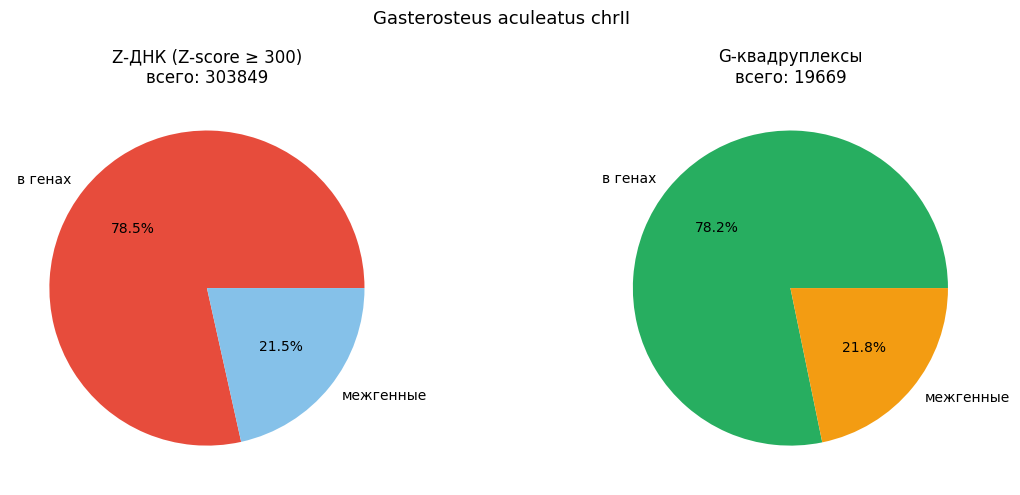

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.pie([n_zdna_genic, n_zdna_inter],
        labels=['в генах', 'межгенные'],
        autopct='%1.1f%%',
        colors=['#E74C3C', '#85C1E9'])
ax1.set_title(f'Z-ДНК (Z-score ≥ 300)\nвсего: {n_zdna}')

ax2.pie([n_g4_genic, n_g4_inter],
        labels=['в генах', 'межгенные'],
        autopct='%1.1f%%',
        colors=['#27AE60', '#F39C12'])
ax2.set_title(f'G-квадруплексы\nвсего: {n_g4}')

plt.suptitle(f'Gasterosteus aculeatus chrII', fontsize=13)
plt.tight_layout()
plt.savefig('distribution.png', dpi=150)
plt.show()

In [40]:
print('Результаты')
print(f'Z-ДНК участков (Z >= 300): {n_zdna}')
print(f'в генах: {n_zdna_genic}')
print(f'межгенные: {n_zdna_inter}')
print(f'G4 участков: {n_g4}')
print(f'в генах: {n_g4_genic}')
print(f'межгенные: {n_g4_inter}')
print(f'Генов с Z-ДНК в промоторе: {len(zdna_promo_genes)}')
print(f'Генов с G4 в промоторе: {len(g4_promo_genes)}')

Результаты
Z-ДНК участков (Z >= 300): 303849
в генах: 238479
межгенные: 65370
G4 участков: 19669
в генах: 15389
межгенные: 4280
Генов с Z-ДНК в промоторе: 2774
Генов с G4 в промоторе: 903
